<a href="https://colab.research.google.com/github/yxmauw/eye-disease-classification/blob/main/NasNetLarge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="http://imgur.com/1ZcRyrc.png" width="70" height="70" align="left" style="margin: 20px"> 
 # Capstone: Eye Disease Classification using Fundoscopy images

## Setting up local directory to work
Stream data direct from kaggle using Kaggle API

In [ ]:
# install kaggle API if never done before for your google account
# !pip install kaggle

In [1]:
!git clone https://github.com/yxmauw/eye-disease-classification.git

Cloning into 'eye-disease-classification'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 217 (delta 49), reused 0 (delta 0), pack-reused 134
Receiving objects: 100% (217/217), 25.25 MiB | 15.70 MiB/s, done.
Resolving deltas: 100% (126/126), done.


In [2]:
!mkdir ~/.kaggle #Make a directory named “.kaggle”

In [3]:
!cp ./eye-disease-classification/kaggle.json ~/.kaggle/ # Copy the “kaggle.json” into this new directory

In [4]:
!chmod 600 ~/.kaggle/kaggle.json # Allocate the required permission for this file

In [5]:
!kaggle datasets download gunavenkatdoddi/eye-diseases-classification # download dataset

 99% 729M/736M [00:05<00:00, 148MB/s]
100% 736M/736M [00:05<00:00, 153MB/s]


In [ ]:
!unzip eye-diseases-classification.zip

## Explore images

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

### Number of images in dataset:

In [8]:
import fnmatch
import os

# image files count
cataract_count = len(fnmatch.filter(os.listdir('./dataset/cataract'), '*.*'))
dre_count = len(fnmatch.filter(os.listdir('./dataset/diabetic_retinopathy'), '*.*'))
glaucoma_count = len(fnmatch.filter(os.listdir('./dataset/glaucoma'), '*.*'))
normal_count = len(fnmatch.filter(os.listdir('./dataset/normal'), '*.*'))
total_image_count = cataract_count + dre_count + \
                    glaucoma_count + normal_count
# print count
print('---Categories---')
print('Cataract:', cataract_count)
print('Diabetic retinopathy:', dre_count)
print('Glaucoma:', glaucoma_count)
print('Normal', normal_count)
print()
print('---Total image count---')
print(total_image_count)

---Categories---
Cataract: 1038
Diabetic retinopathy: 1098
Glaucoma: 1007
Normal 1074

---Total image count---
4217


### Image dimensions, properties:

In [9]:
# load example image
from PIL import Image 
im = Image.open('./dataset/glaucoma/1495_left.jpg')
# summarize some details about the image
print(im.format)
print(im.mode)
print(im.size) # size already 512 x 512

pixels = np.asarray(im)
print(pixels[0])
print(pixels.shape) # 3 channel last

JPEG
RGB
(512, 512)
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
(512, 512, 3)


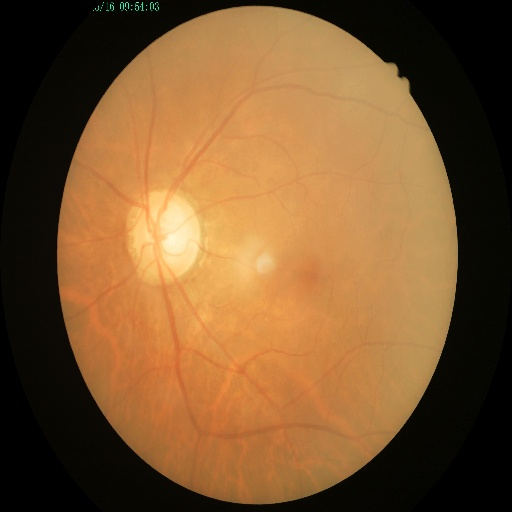

In [ ]:
#Import library
from IPython import display
display.Image(filename='./dataset/glaucoma/1495_left.jpg', width=200, height=150)

In [10]:
# calculate image pixel mean, min, max

mean = pixels.mean()
print('Mean: %.3f' % mean)
# confirm pixel range is 0-255
print('Min: %.3f, Max: %.3f' % (pixels.min(), pixels.max()))

Mean: 86.173
Min: 0.000, Max: 255.000


## Visualise preprocessed images

In [11]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__) #2.8.2

2.8.2


What happens after resizing and rescaling: 

In [12]:
resize_and_rescale = tf.keras.Sequential([   
    layers.Resizing(331,331) ,  # needs to be symmetrical, specific size for nasnetlarge
    layers.Rescaling(1./255) # desired height, width in model pipeline
])

result = resize_and_rescale(pixels)
print(result.shape) # new shape, channels

(331, 331, 3)


What happens to image pixel values after rescaling:

In [ ]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


Show images before and after preprocessing:

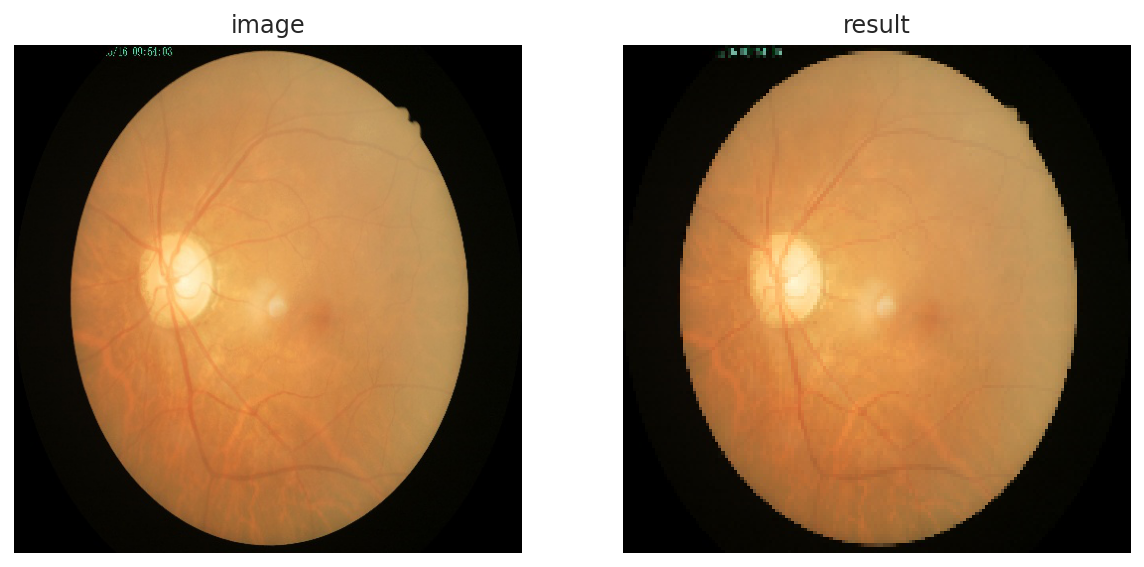

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,8))
ax0.imshow(im)
ax0.axis('off')
ax0.set_title('image')
# after pixel normalisation
ax1.imshow(result)
ax1.axis('off')
ax1.set_title('result')
plt.show() # result seems to have slight blurring of image, but still good definition

## Create train, validation and test datasets

In [13]:
!pip install split-folders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [14]:
# first allocate a test set using this library
import splitfolders

splitfolders.ratio('./dataset/', output="./work_directory/", seed=1, ratio=(.8,.15,.05))

Copying files: 4217 files [00:01, 2702.60 files/s]


In [18]:
# generate dataset that can be used for machine learning
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (331, 331) # very important to get this right, will determine model success
batch_size = 32

train_ds = image_dataset_from_directory(
    './work_directory/train',
    image_size=image_size,
    shuffle=True,
    labels='inferred',
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    './work_directory/val',
    image_size=image_size,
    shuffle=True,
    labels='inferred',
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory( # for model evaluation later
    './work_directory/test',
    image_size=image_size,
    labels='inferred',
    seed=1,
    shuffle=False,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 3372 files belonging to 4 classes.
Found 631 files belonging to 4 classes.
Found 214 files belonging to 4 classes.


### Visualise images and labels together

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


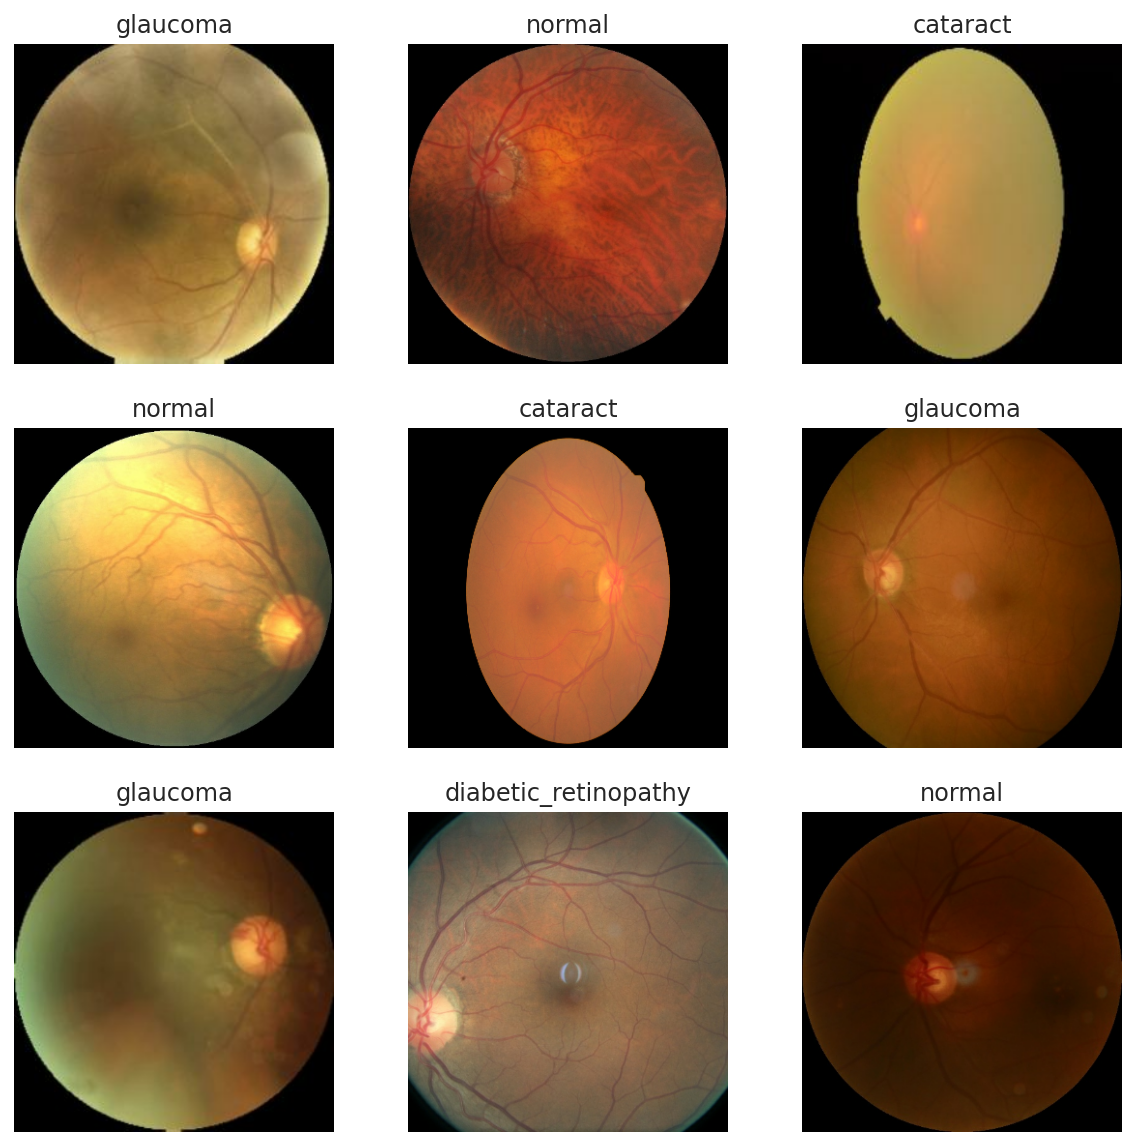

In [19]:
# preview of how images are labelled
class_names = train_ds.class_names
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")

## Data augmentation

In [20]:
data_augmentation = tf.keras.Sequential(
    [ layers.RandomFlip("horizontal_and_vertical", seed=123), 
      layers.RandomRotation(0.1, seed=123),
      layers.RandomContrast(0.1, seed=123)
    ])

### Visualise augmented images

In [21]:
def augmented_img():
  for image, _ in train_ds.take(1):  # take a sample image from training set
    plt.figure(figsize=(8, 8))
    first_image = image[0]
    for i in range(9):
      ax = plt.subplot(3, 3, i + 1)
      augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
      plt.imshow(augmented_image[0] / 255) # rescale pixel 0 to 1
      plt.axis("off")

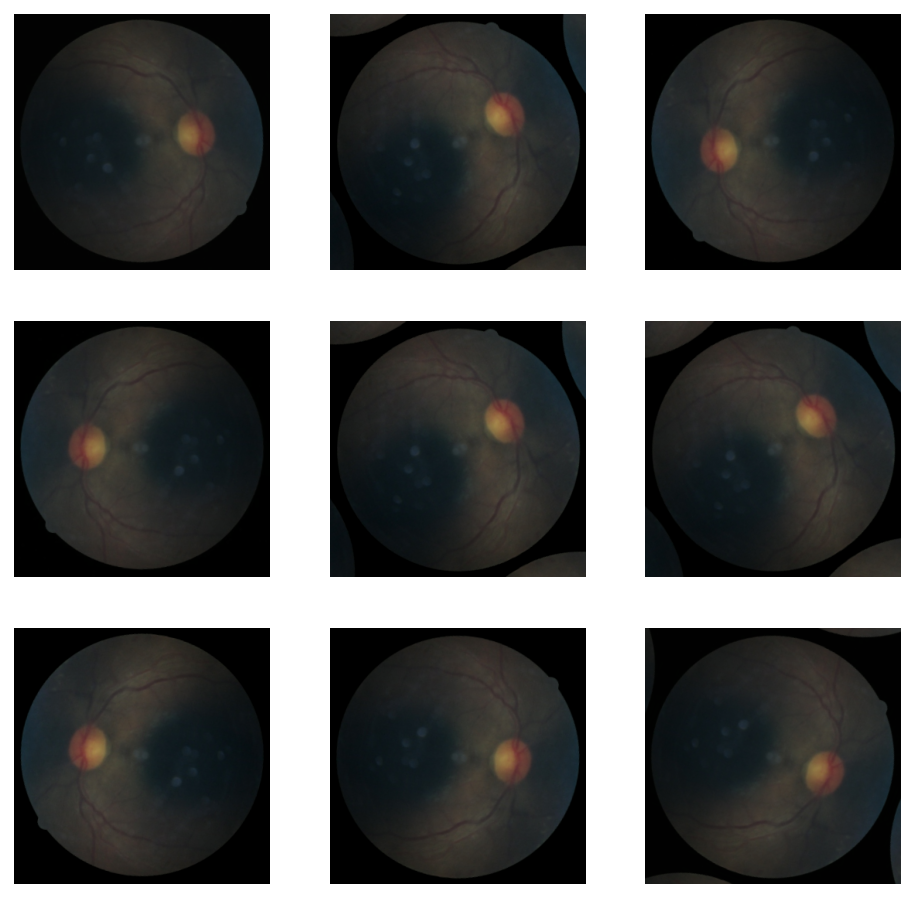

In [22]:
augmented_img()

## Create Base NasNetLarge model



In [25]:
# Create the base model from the pre-trained NASNetLarge model
input_shape = (331, 331, 3)
base_model = tf.keras.applications.NASNetLarge(input_shape=input_shape,
                                               include_top=False,
                                               weights='imagenet',
                                               classes=4,
                                               pooling='max'
                                               )

343621632/343610240 [==============================] - 2s 0us/step


In [26]:
base_model.trainable=True # train entire model layers, yet with pre-trained weights from ImageNet

In [27]:
from tensorflow.keras.layers import (Dense, Activation, Dropout, Conv2D, 
                                     MaxPooling2D, BatchNormalization)
from tensorflow.keras import regularizers

In [28]:
def NasNetL():
  # add rescaling layer to base model
  inputs = tf.keras.Input(shape=(331, 331, 3))
  x = tf.keras.layers.Rescaling(1./255)(inputs) # rescaling layer
  x = base_model(x, training=True)
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model = tf.keras.Model(inputs, output)
  return model

In [29]:
model = NasNetL()

In [30]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 331, 331, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 331, 331, 3)       0         
                                                                 
 NASNet (Functional)         (None, 4032)              84916818  
                                                                 
 batch_normalization (BatchN  (None, 4032)             16128     
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               1032448   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                             

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
# show model in graph manner
tf.keras.utils.plot_model(model, to_file = "drive/MyDrive/Colab Notebooks/NasNetLarge.png", show_shapes=True)

## Compile, fit model, run

[getting F1 score in metrics](https://aakashgoel12.medium.com/how-to-add-user-defined-function-get-f1-score-in-keras-metrics-3013f979ce0d)

In [32]:
import keras.backend as K # function to add F1 score as metric

def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [34]:
METRICS = [
      tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
      f1_score
]

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=METRICS)

# Train the model, doing validation at the end of each epoch.
epochs = 100 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/NasNet_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/NasNet_history.csv'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=3,verbose=1,mode='min',min_lr=0.00001)
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/100
  5/106 [>.............................] - ETA: 21:49 - loss: 11.1654 - categorical_accuracy: 0.4563 - precision: 0.4690 - recall: 0.4250 - auc: 0.6883 - f1_score: 0.4377

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.689798,0.880401,0.682916,6.738587,0.640254,0.859393,0.636181,4.860488
1,1,0.825919,0.959957,0.819005,3.046620,0.839937,0.955022,0.830523,2.100375
2,2,0.879893,0.978204,0.874795,1.459945,0.885895,0.975571,0.875568,1.063100


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

In [ ]:
def learning_curves(acc,val_acc,loss,val_loss):
  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(acc, label='Training Accuracy')
  plt.plot(val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.ylabel('Accuracy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Training Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.ylabel('Cross Entropy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Loss')
  plt.xlabel('epoch')
  plt.show()
  return plt.show()

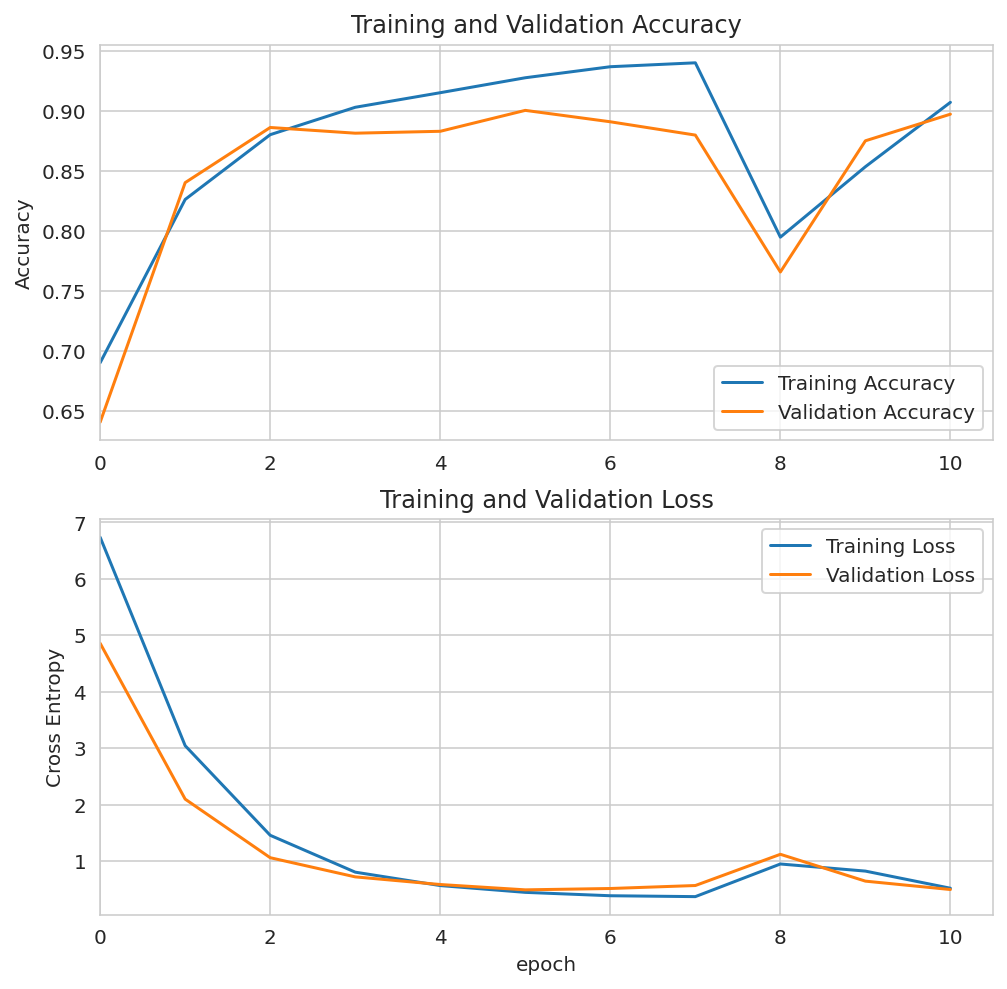

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

In [ ]:
# check for generalisation for epoch 6
def metrics(epoch_num):
  val_auc = history.loc[history['epoch']==epoch_num, ['val_auc']].values[0][0]
  auc = history.loc[history['epoch']==epoch_num, ['auc']].values[0][0]
  auc_diff = (auc - val_auc)*100 / auc
  print('AUC percentage difference is:', abs(auc_diff), '%')

  val_acc = history.loc[history['epoch']==epoch_num, ['val_accuracy']].values[0][0]
  acc = history.loc[history['epoch']==epoch_num, ['accuracy']].values[0][0]
  acc_diff = (acc - val_acc)*100 / acc
  print()
  print('Accuracy percentage difference is:', abs(acc_diff), '%')

In [ ]:
metrics(epoch_num=5) # 8 because record epoch 6 as 5

AUC percentage difference is: 0.7998924740821824 %

Accuracy percentage difference is: 2.9314258156984443 %


Best base EfficientNet model found with the following validation metrics:

| Name     |   Scores   |
|:---------|:----------:|
|Accuracy  |0.9001584649|
|AUC       |0.9827708006|
|F1 score  |0.9015578032|
|Loss      |0.4938850701|

There is also good generalisation within 5%. 


## EfficientNet model with augmentation layers

adding data augmentation layers, try running EfficientNet with data augmentation layers, and see if can get better performance, yet still maintain model generalisation.

In [ ]:
 # add rescaling layer to base model
 def E_Net_augmented():
  inputs = tf.keras.Input(shape=(160, 160, 3))
  x = data_augmentation(inputs) # augmentation layer
  x = tf.keras.layers.Rescaling(1./255)(x) # rescaling layer
  x = base_model(x, training=True)
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model = tf.keras.Model(inputs, output)
  return model

In [ ]:
model = E_Net_augmented()

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 160, 160, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 batch_normalization (BatchN  (None, 1536)             6144      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               393472

## Compile, fit model, run

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC',get_f1])

# Train the model, doing validation at the end of each epoch.
epochs = 50 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/ENet_augm_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/ENet_history_augm.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/50
106/106 [==============================] - 314s 3s/step - loss: 6.1905 - accuracy: 0.7423 - auc: 0.9105 - get_f1: 0.7339 - val_loss: 3.8411 - val_accuracy: 0.8035 - val_auc: 0.9470 - val_get_f1: 0.7859
Epoch 2/50
106/106 [==============================] - 305s 3s/step - loss: 2.7548 - accuracy: 0.8304 - auc: 0.9582 - get_f1: 0.8265 - val_loss: 1.8472 - val_accuracy: 0.8827 - val_auc: 0.9697 - val_get_f1: 0.8527
Epoch 3/50
106/106 [==============================] - 289s 3s/step - loss: 1.4082 - accuracy: 0.8577 - auc: 0.9701 - get_f1: 0.8523 - val_loss: 1.0265 - val_accuracy: 0.8811 - val_auc: 0.9748 - val_get_f1: 0.8556
Epoch 4/50
106/106 [==============================] - 312s 3s/step - loss: 0.8771 - accuracy: 0.8734 - auc: 0.9731 - get_f1: 0.8639 - val_loss: 0.7288 - val_accuracy: 0.8764 - val_auc: 0.9789 - val_get_f1: 0.8776
Epoch 5/50
106/106 [==============================] - 293s 3s/step - loss: 0.6523 - accuracy: 0.8861 - auc: 0.9783 - get_f1: 0.8810 - val_loss: 0.56

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history_augm.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.742289,0.910531,0.733939,6.190459,0.803487,0.947016,0.785884,3.841105
1,1,0.830368,0.958226,0.826476,2.754832,0.882726,0.969655,0.852743,1.847231
2,2,0.857651,0.970128,0.852349,1.408215,0.881141,0.974798,0.855625,1.026509


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

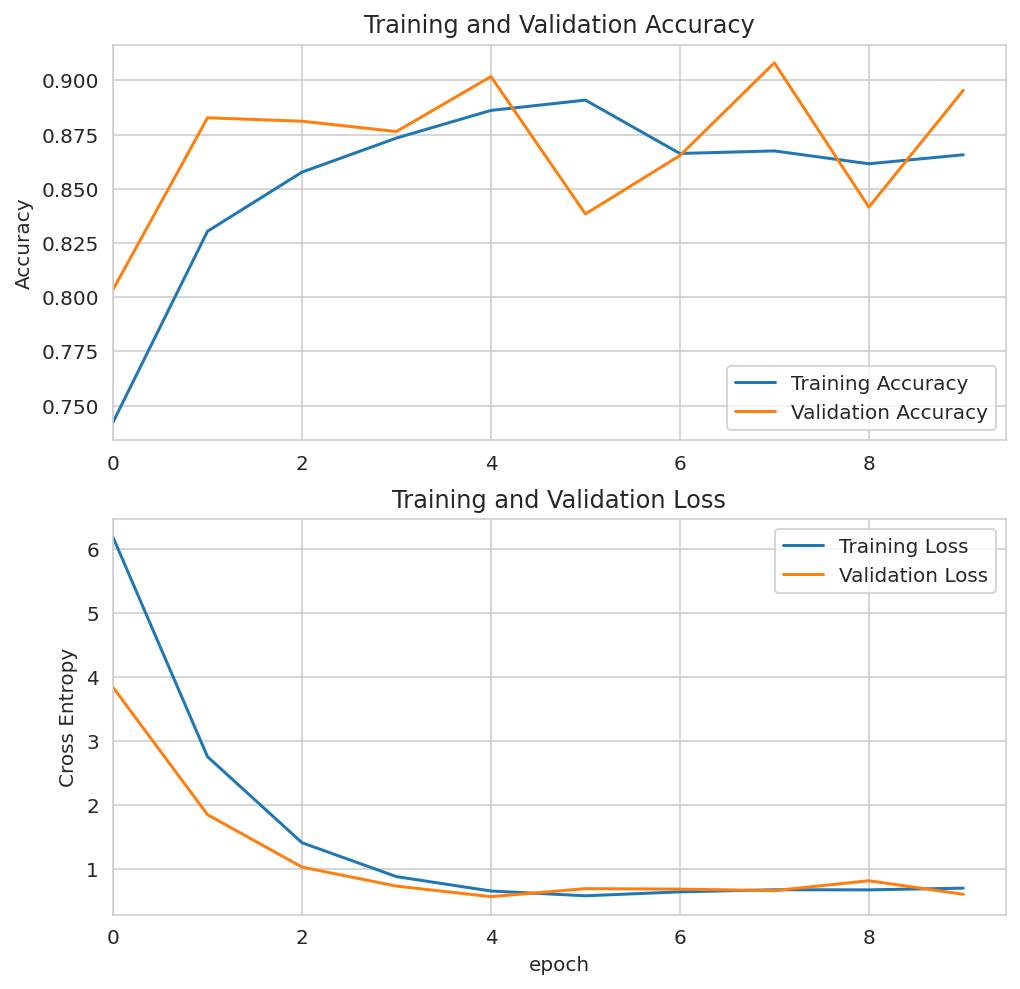

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

In [ ]:
# check for generalisation using epoch 5
metrics(epoch_num=4)

AUC percentage difference is: 0.13502949501600853 %

Accuracy percentage difference is: 1.7630005644179514 %


Initially, I did model running without allocating a test dataset. I just had training and validation datasets. With that arrangement, I managed to achieve good results with EfficientNet model (data augmentation layers included, Adam optimizer).

However, after allocating a test dataset, my model does not seem to learn as well, has a lower best accuracy and f1_score. 

In fact, it seems that adding data augmentation layers did not seem to improve model performance significantly.

Let's try base model with SGD Optimizer to see if accuracy can be improved further.

## Try with SGD Optimiser, to see if can improve accuracy score further
using base model

In [ ]:
# instantiate augmented model
model = E_Net()
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 batch_normalization_2 (Batc  (None, 1536)             6144      
 hNormalization)                                                 
                                                                 
 dense_4 (Dense)             (None, 256)               393472    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0   

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC', get_f1])

# Train the model, doing validation at the end of each epoch.
epochs = 50

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/ENet_sgd_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/ENet_history_sgd.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/50
106/106 [==============================] - 304s 3s/step - loss: 7.6983 - accuracy: 0.8728 - auc: 0.9770 - get_f1: 0.8643 - val_loss: 7.3950 - val_accuracy: 0.8986 - val_auc: 0.9818 - val_get_f1: 0.8999
Epoch 2/50
106/106 [==============================] - 282s 3s/step - loss: 6.9549 - accuracy: 0.9324 - auc: 0.9924 - get_f1: 0.9310 - val_loss: 6.7405 - val_accuracy: 0.9128 - val_auc: 0.9861 - val_get_f1: 0.9074
Epoch 3/50
106/106 [==============================] - 278s 3s/step - loss: 6.4660 - accuracy: 0.9333 - auc: 0.9916 - get_f1: 0.9332 - val_loss: 6.3103 - val_accuracy: 0.9049 - val_auc: 0.9833 - val_get_f1: 0.9045
Epoch 4/50
106/106 [==============================] - 275s 3s/step - loss: 6.0151 - accuracy: 0.9380 - auc: 0.9938 - get_f1: 0.9376 - val_loss: 5.8994 - val_accuracy: 0.9065 - val_auc: 0.9835 - val_get_f1: 0.9011
Epoch 5/50
106/106 [==============================] - 282s 3s/step - loss: 5.6266 - accuracy: 0.9377 - auc: 0.9939 - get_f1: 0.9359 - val_loss: 5.53

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history_sgd.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.872776,0.976971,0.864250,7.698271,0.898574,0.981807,0.899925,7.394993
1,1,0.932384,0.992415,0.931045,6.954866,0.912837,0.986053,0.907446,6.740544
2,2,0.933274,0.991648,0.933240,6.465984,0.904913,0.983299,0.904546,6.310316


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

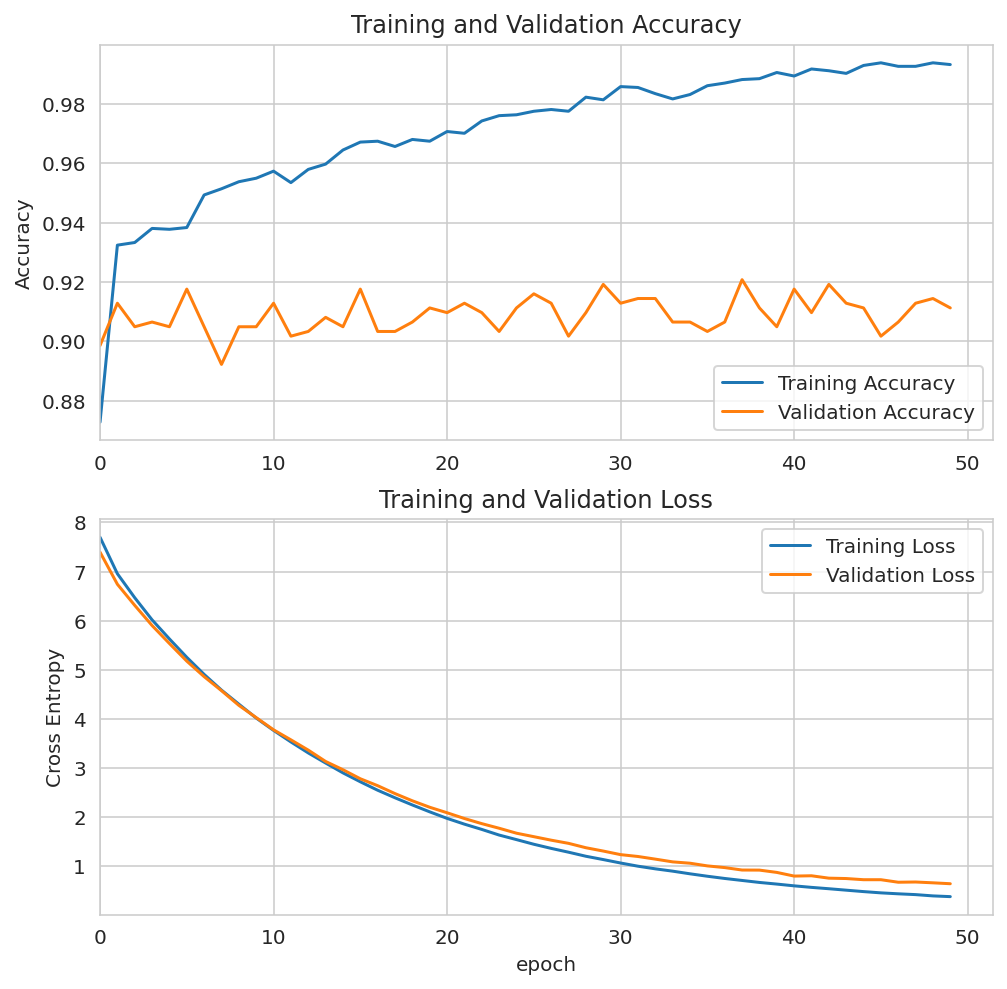

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

Even though model with SGD optimizer have generally slightly better validation metrics compared to the base and augmented models, however the model is overfitted. 
So I have to consider between the base model and augmented models. The base model has a slightly better overall validation metric compared to model with data augmentation layer. Therefore, I will be using base model for further evaluation.

## Evaluation

using test dataset

__References:__
1. [images](https://machinelearningmastery.com/image-augmentation-with-keras-preprocessing-layers-and-tf-image/)
1. [kaggle code](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook)

In [ ]:
# choose model for evaluation
# load model
model = tf.keras.models.load_model("drive/MyDrive/Colab Notebooks/ENet_ep6_val0.494", 
                                   custom_objects={'get_f1': get_f1})

### Confusion matrix

In [ ]:
# for predictions
# class_names = train_ds.class_names # from previous cell
print(class_names)

preds = model.predict(test_ds, verbose=1)
print(preds[:1])
for array in preds:
  print(f'{class_names[0]} probability is: {array[0]:.4f}')
  print(f'{class_names[1]} probability is: {array[1]:.4f}')
  print(f'{class_names[2]} probability is: {array[2]:.4f}')
  print(f'{class_names[3]} probability is: {array[3]:.4f}')
  break

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
7/7 [==============================] - 5s 330ms/step
[[0.16316426 0.36151257 0.27616972 0.19915336]]
cataract probability is: 0.1632
diabetic_retinopathy probability is: 0.3615
glaucoma probability is: 0.2762
normal probability is: 0.1992


In [ ]:
y_true = [] 
y_pred = []
image_list = []
for images, true_labels in test_ds.take(-1): # to iterate through all batches in test_ds
  # for y_true
  y_true.append(true_labels)
  image_list.append(images)
  # for y_pred
  preds = model.predict(images)
  idx = np.argmax(preds, axis=-1)
  preds = np.zeros( preds.shape ) # convert probabilities into OHE
  preds[ np.arange(preds.shape[0]), idx] = 1  
  y_pred.append(preds)
  
# because end result are nested arrays representing each batch (5), 
# to make it a continuous array, use np.concatenate
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# print('True labels:', true_labels.argmax(axis=1)[:5])
print('True labels:', true_labels[:5])
print('Predicted labels:', preds[:5])

True labels: tf.Tensor(
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]], shape=(5, 4), dtype=float32)
Predicted labels: [[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]


[Multiclass confusion matrix](https://www.analyticsvidhya.com/blog/2021/06/confusion-matrix-for-multi-class-classification/#:~:text=Confusion%20Matrix%20is%20used%20to,number%20of%20classes%20or%20outputs.)


In [ ]:
# confusion matrix using seaborn heatmap
from sklearn.metrics import confusion_matrix
# Creating  a confusion matrix,which compares the y_test and y_pred
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))

# Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
cm_df = pd.DataFrame(cm,
                     index = class_names, 
                     columns = class_names)

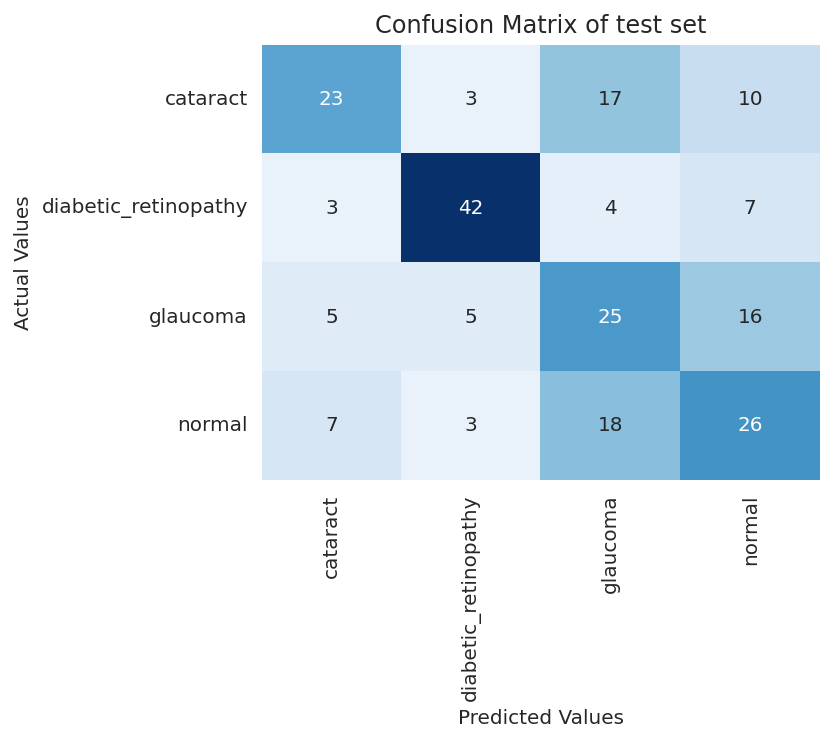

In [ ]:
#Plotting confusion matrix using heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cbar=False, cmap='Blues', vmin=0, fmt='.3g', annot_kws={"size": 10})
plt.title('Confusion Matrix of test set')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

### Classification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names, digits= 4))

                      precision    recall  f1-score   support

            cataract     0.6053    0.4340    0.5055        53
diabetic_retinopathy     0.7925    0.7500    0.7706        56
            glaucoma     0.3906    0.4902    0.4348        51
              normal     0.4407    0.4815    0.4602        54

           micro avg     0.5421    0.5421    0.5421       214
           macro avg     0.5573    0.5389    0.5428       214
        weighted avg     0.5616    0.5421    0.5466       214
         samples avg     0.5421    0.5421    0.5421       214



Model is not great at identifying glaucoma compared to other conditions, which makes sense due to the lowest support in the dataset. The model is best at identifying diabetic retinopathy.

## Misclassified test images

In [ ]:
image_list = np.concatenate(image_list) # numpy array representation of images

In [ ]:
# extract test file names from test_ds 
# glitchy code, sometimes can run sometimes throw error, not sure why
test_filenames = test_ds.file_paths

In [ ]:
len(test_filenames)

214

In [ ]:
# convert OHE to class_names for easier comparison 
y_true_labels = tf.argmax(y_true, axis=1).numpy() # tensor object not iterable, use numpy to convert to list
y_pred_labels = tf.argmax(y_pred, axis=1).numpy()

error_list = []

for a, b, c in zip(y_true_labels, y_pred_labels, test_filenames):
  if a != b:
    error_list.append((a,b,c))

In [ ]:
len(error_list)

98

In [ ]:
error_list[:5] # check for duplicates

[(0, 1, './work_directory/test/cataract/1084_right.jpg'),
 (0, 1, './work_directory/test/cataract/112_right.jpg'),
 (0, 2, './work_directory/test/cataract/1456_left.jpg'),
 (0, 3, './work_directory/test/cataract/1484_left.jpg'),
 (0, 3, './work_directory/test/cataract/1987_left.jpg')]

In [ ]:
# to display 3 example of each class that was wrongly classified

fig, axes = plt.subplots(4, 5, figsize=(8, 15))

for true_label, pred_label, f_path, ax in zip(error_list, axes.ravel()): 
  img = Image.open(f_path)
  ax.imshow(img)
    
  #plt.imshow(image.astype('uint8'))
  #for i in range(10):
    #ax[i].imshow(image.astype('uint8'))
    
    #plt.title(class_names[true_label[i]])
    #plt.subtitle(class_names[pred_label[i]])
    #plt.axis("off")
'''
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")
'''

In [ ]:
# compare images with true vs predicted labels

In [ ]:
for images, labels in train_ds.take(1): # each image 160 x 160
 # print(images[i])
  print(images[i].numpy())
  break

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
(160, 160, 3)


### ROC curve only if comparing with another model

In [ ]:
# ROC curve

In [ ]:
# PR curve